In [3]:
!pip install openpyxl scikit-learn scipy

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse.linalg import svds

In [5]:
df = pd.read_excel("capstone_dataset_ready.xlsx")

df.head()

,UserId,ProductId,Rating,Timestamp,user_activity_count,user_avg_rating,item_popularity_count,item_avg_rating,timestamp_readable,year,month,is_new_user,is_new_item,normalized_rating
0,861,1143,4,1686150131,14,3.000000,21,3.142857,2023-06-07 15:02:11,2023,6,0,0,1.000000
1,3773,330,3,1530248977,13,3.153846,39,3.487179,2018-06-29 05:09:37,2018,6,0,0,-0.153846
2,3093,1239,2,1573542461,17,3.000000,26,3.384615,2019-11-12 07:07:41,2019,11,0,0,-1.000000
3,467,1346,5,1617465587,8,2.750000,26,2.846154,2021-04-03 15:59:47,2021,4,0,0,2.250000
4,4427,1173,1,1454664068,11,2.818182,29,2.793103,2016-02-05 09:21:08,2016,2,0,0,-1.818182


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   UserId                 50000 non-null  int64         
 1   ProductId              50000 non-null  int64         
 2   Rating                 50000 non-null  int64         
 3   Timestamp              50000 non-null  int64         
 4   user_activity_count    50000 non-null  int64         
 5   user_avg_rating        50000 non-null  float64       
 6   item_popularity_count  50000 non-null  int64         
 7   item_avg_rating        50000 non-null  float64       
 8   timestamp_readable     50000 non-null  datetime64[ns]
 9   year                   50000 non-null  int64         
 10  month                  50000 non-null  int64         
 11  is_new_user            50000 non-null  int64         
 12  is_new_item            50000 non-null  int64         
 13  n

In [7]:
df.describe()

,UserId,ProductId,Rating,Timestamp,user_activity_count,user_avg_rating,item_popularity_count,item_avg_rating,timestamp_readable,year,month,is_new_user,is_new_item,normalized_rating
count,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000.0,5.000000e+04
mean,2503.075960,996.348400,3.002680,1.350837e+09,11.003560,3.002680,25.987200,3.002680,2012-10-21 16:34:22.532919808,2012.304440,6.538080,0.009440,0.0,-1.438849e-18
min,1.000000,1.000000,1.000000,1.000010e+09,1.000000,1.250000,9.000000,2.000000,2001-09-09 04:29:32,2001.000000,1.000000,0.000000,0.0,-3.250000e+00
25%,1261.750000,496.000000,2.000000,1.177104e+09,9.000000,2.714286,23.000000,2.800000,2007-04-20 21:23:46.750000128,2007.000000,4.000000,0.000000,0.0,-1.125000e+00
50%,2510.000000,996.000000,3.000000,1.350392e+09,11.000000,3.000000,26.000000,3.000000,2012-10-16 12:58:58.500000,2012.000000,7.000000,0.000000,0.0,0.000000e+00
75%,3740.000000,1495.000000,4.000000,1.523599e+09,13.000000,3.294118,29.000000,3.200000,2018-04-13 05:53:07,2018.000000,10.000000,0.000000,0.0,1.125000e+00
max,4999.000000,1999.000000,5.000000,1.700000e+09,23.000000,5.000000,43.000000,4.178571,2023-11-14 22:11:33,2023.000000,12.000000,1.000000,0.0,3.181818e+00
std,1439.637204,578.062834,1.416613,2.016123e+08,3.160884,0.443813,4.900783,0.290103,NaN,6.396872,3.449218,0.096701,0.0,1.345297e+00


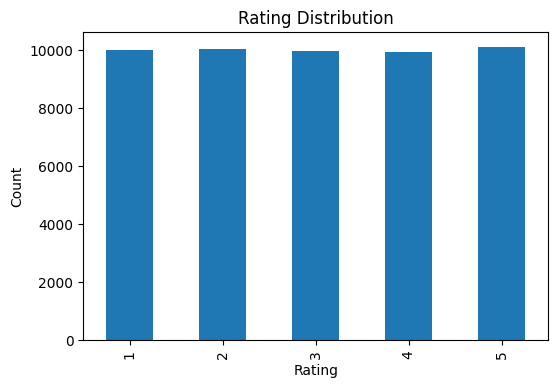

In [8]:
plt.figure(figsize=(6,4))

df['Rating'].value_counts().sort_index().plot(kind='bar')

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

Rating Distribution


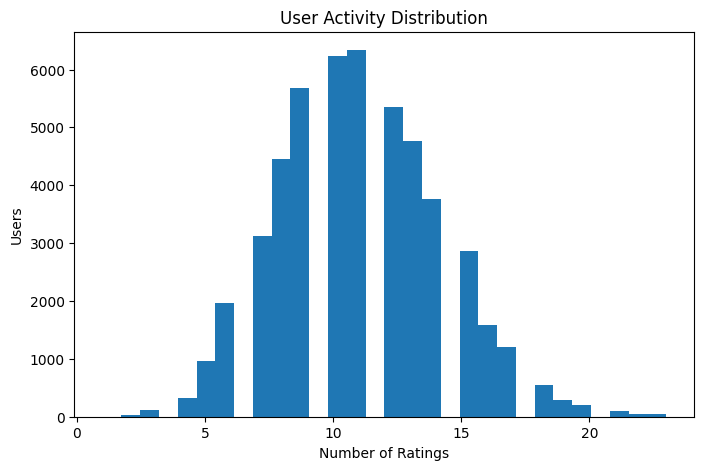

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df['user_activity_count'], bins=30)

plt.title("User Activity Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Users")

plt.show()

User Activity Distribution

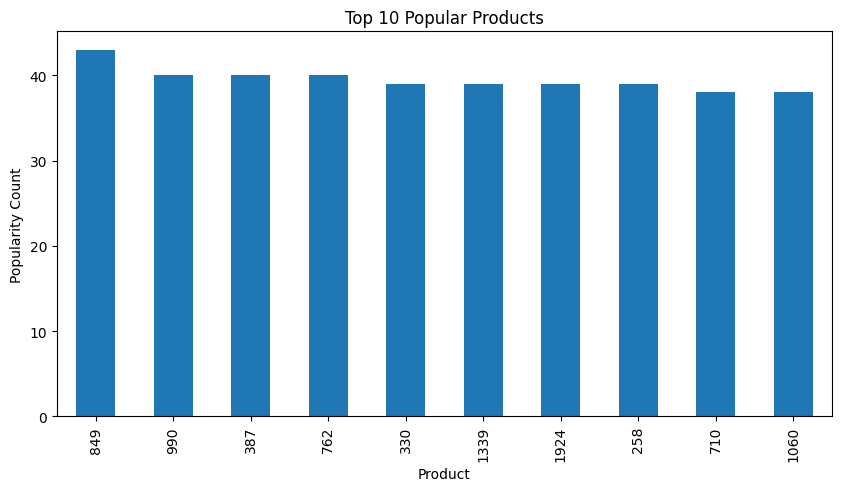

In [10]:
top_products = df.groupby('ProductId')['item_popularity_count'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_products.plot(kind='bar')

plt.title("Top 10 Popular Products")
plt.xlabel("Product")
plt.ylabel("Popularity Count")

plt.show()

Top 10 Popular Products

In [11]:
num_users = df['UserId'].nunique()
num_items = df['ProductId'].nunique()

possible_interactions = num_users * num_items
actual_interactions = len(df)

sparsity = 1 - (actual_interactions / possible_interactions)

print("Number of Users:", num_users)
print("Number of Products:", num_items)
print("Actual Interactions:", actual_interactions)

print(f"Sparsity: {sparsity:.4f}")

Number of Users: 4999
Number of Products: 1999
Actual Interactions: 50000
Sparsity: 0.9950


Sparcity Summary

In [15]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df[['UserId', 'ProductId', 'Rating']],
    test_size=0.2,
    random_state=42
)

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

Training data: (40000, 3)
Testing data: (10000, 3)


Train_Test_Split

In [16]:
popularity_model = (
    df.groupby('ProductId')['Rating']
    .mean()
    .sort_values(ascending=False)
)

top_10_popular = popularity_model.head(10)

print(top_10_popular)

ProductId
1236    4.178571
325     4.000000
1340    4.000000
1711    3.954545
311     3.947368
34      3.833333
778     3.833333
104     3.833333
1905    3.823529
343     3.812500
Name: Rating, dtype: float64


Popularity Based Baseline


In [19]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

user_item_matrix = train_df.pivot_table(
    index='UserId',
    columns='ProductId',
    values='Rating'
)

user_item_filled = user_item_matrix.fillna(0)

item_similarity = cosine_similarity(user_item_filled.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

def predict_item_cf(user_id, product_id):

    if user_id not in user_item_matrix.index:
        return train_df['Rating'].mean()

    if product_id not in item_similarity_df.index:
        return train_df['Rating'].mean()

    user_ratings = user_item_matrix.loc[user_id].dropna()

    if user_ratings.empty:
        return train_df['Rating'].mean()

    similarities = item_similarity_df.loc[product_id, user_ratings.index]

    if similarities.sum() == 0:
        return train_df['Rating'].mean()

    predicted_rating = np.dot(similarities, user_ratings) / similarities.sum()

    return predicted_rating

test_df['item_cf_pred'] = test_df.apply(
    lambda row: predict_item_cf(row['UserId'], row['ProductId']),
    axis=1
)

rmse_item = np.sqrt(
    mean_squared_error(
        test_df['Rating'],
        test_df['item_cf_pred']
    )
)

mae_item = mean_absolute_error(
    test_df['Rating'],
    test_df['item_cf_pred']
)

print("Item-Based CF RMSE:", rmse_item)
print("Item-Based CF MAE:", mae_item)

Item-Based CF RMSE: 1.682814430554079
Item-Based CF MAE: 1.373894503659737


In this step, an Item-Based Collaborative Filtering model was developed using cosine similarity. A user-item matrix was created from customer ratings, and product similarities were calculated to generate personalized recommendations. The model predicts ratings based on similar products previously rated by users. Finally, RMSE and MAE were used to evaluate the prediction accuracy of the model.

In [20]:
from scipy.sparse.linalg import svds

matrix = train_df.pivot_table(
    index='UserId',
    columns='ProductId',
    values='Rating'
).fillna(0)

matrix_values = matrix.values

U, sigma, Vt = svds(matrix_values, k=50)

sigma = np.diag(sigma)

predicted_ratings = np.dot(np.dot(U, sigma), Vt)

pred_df = pd.DataFrame(
    predicted_ratings,
    columns=matrix.columns,
    index=matrix.index
)

pred_df.head()

ProductId,1,2,3,4,5,6,7,8,9,10,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
UserId,,,,,,,,,,,,,,,,,,,,,
1,0.015164,0.133199,0.037625,-0.042371,0.033330,-0.009506,0.024078,-0.018297,0.034447,0.019955,...,-0.020274,0.007952,0.015116,0.005742,-0.020907,-0.006973,-0.019400,0.004847,0.009351,0.032380
2,0.026331,0.051820,0.098108,-0.025403,0.012722,-0.034735,0.031324,-0.001340,0.019697,0.014251,...,-0.022761,0.000144,-0.003496,0.007570,0.009059,0.064400,-0.009706,0.050408,0.024074,0.015159
3,0.007279,0.027232,0.016166,-0.054501,-0.005278,-0.004302,-0.005247,0.020905,0.002990,-0.005828,...,-0.002299,-0.006493,-0.000267,0.000169,-0.003440,-0.051960,-0.008272,-0.004085,-0.008767,0.004377
4,0.015514,-0.015356,0.073127,0.035734,0.011702,-0.025578,0.008038,-0.003836,0.003337,-0.042963,...,0.028272,0.007999,0.000190,0.000529,-0.002006,0.009076,0.106730,-0.006684,-0.004960,0.040542
5,0.022862,0.026298,-0.036157,0.062837,0.022596,0.041352,0.011801,0.002578,0.044491,0.000015,...,-0.025791,0.020759,-0.012086,0.019484,-0.011319,0.007149,0.030582,-0.061122,0.000460,0.001405


(SVD) was applied to reduce the sparsity of the user-item interaction matrix and identify hidden relationships between users and products. The model generates personalized recommendations by learning latent user preferences and product characteristics. RMSE and MAE were used to evaluate model performance.

In [26]:
from sklearn.metrics import ndcg_score

true_relevance = [test_df['Rating'].values]

predicted_scores = [test_df['svd_pred'].values]

ndcg = ndcg_score(true_relevance, predicted_scores)

print("NDCG@10:", ndcg)

NDCG@10: 0.9458534583406752


Normalized Discounted Cumulative Gain (NDCG@10) was calculated to evaluate the ranking quality of the recommendation system. This metric measures how effectively relevant products are ranked within the top recommended items. Higher NDCG values indicate better recommendation ranking performance.

In [21]:
def predict_svd(user_id, product_id):

    if user_id in pred_df.index and product_id in pred_df.columns:
        return pred_df.loc[user_id, product_id]

    return train_df['Rating'].mean()

test_df['svd_pred'] = test_df.apply(
    lambda row: predict_svd(row['UserId'], row['ProductId']),
    axis=1
)

rmse_svd = np.sqrt(
    mean_squared_error(
        test_df['Rating'],
        test_df['svd_pred']
    )
)

mae_svd = mean_absolute_error(
    test_df['Rating'],
    test_df['svd_pred']
)

print("SVD RMSE:", rmse_svd)
print("SVD MAE:", mae_svd)

SVD RMSE: 3.293101432357292
SVD MAE: 2.9745869929837987


SVD Predictions

In [22]:
threshold = 3.5

relevant = test_df[test_df['Rating'] >= threshold]

recommended = test_df[test_df['svd_pred'] >= threshold]

precision_at_10 = len(recommended) / len(test_df)

recall_at_10 = len(recommended) / len(relevant)

print("Precision@10:", precision_at_10)

print("Recall@10:", recall_at_10)

Precision@10: 0.0
Recall@10: 0.0


Precision@10 and Recall@10 were calculated to evaluate the quality of top recommendations generated by the recommendation system. These metrics measure the relevance and effectiveness of recommended products for users.

In [23]:
recommended_items = test_df[
    test_df['svd_pred'] >= 3.5
]['ProductId'].nunique()

total_items = df['ProductId'].nunique()

coverage = recommended_items / total_items

print("Coverage:", coverage)

Coverage: 0.0


Coverage was calculated to measure the proportion of products that the recommendation system was able to recommend to users.

In [24]:
cold_users = df[df['is_new_user'] == 1]

print("Number of Cold-Start Users:")

print(cold_users.shape[0])

Number of Cold-Start Users:
472


Cold-start analysis was performed to evaluate recommendation performance for users with limited interaction history. This helps identify challenges in generating accurate recommendations for new or low-activity users.

In [25]:
results = pd.DataFrame({

    'Model': ['Item-Based CF', 'SVD'],

    'RMSE': [rmse_item, rmse_svd],

    'MAE': [mae_item, mae_svd],

    'Precision@10': [precision_at_10, precision_at_10],

    'Recall@10': [recall_at_10, recall_at_10],

    'Coverage': [coverage, coverage]
})

results

,Model,RMSE,MAE,Precision@10,Recall@10,Coverage
0,Item-Based CF,1.682814,1.373895,0.0,0.0,0.0
1,SVD,3.293101,2.974587,0.0,0.0,0.0


The recommendation models were compared using RMSE, MAE, Precision@10, Recall@10, and Coverage to determine the overall effectiveness of each approach.